<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%20mini_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## YB 4조 미니 프로젝트(2) : 와인 품질(Quality) 분류 경진대회



###1.   데이터 확인



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')   ## 데이터를 불러온다

데이터 항목을 미리 보면 다음과 같다.
* index 구분자
* quality 품질
* fixed acidity 산도
* volatile acidity 휘발성산
* citric acid 시트르산
* residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
* chlorides 염화물
* free sulfur dioxide 독립 이산화황
* total sulfur dioxide 총 이산화황
* density 밀도
* pH 수소이온농도
* sulphates 황산염
* alcohol 도수
* type 종류






In [4]:
train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,white
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,red
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,white
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,white
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,white


In [5]:
test.head()

,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,9.0,0.31,0.48,6.6,0.043,11.0,73.0,0.99380,2.90,0.38,11.6,white
1,1,13.3,0.43,0.58,1.9,0.070,15.0,40.0,1.00040,3.06,0.49,9.0,red
2,2,6.5,0.28,0.27,5.2,0.040,44.0,179.0,0.99480,3.19,0.69,9.4,white
3,3,7.2,0.15,0.39,1.8,0.043,21.0,159.0,0.99480,3.52,0.47,10.0,white
4,4,6.8,0.26,0.26,2.0,0.019,23.5,72.0,0.99041,3.16,0.47,11.8,white


In [6]:
sample_submission.head()

,index,quality
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [7]:
train.isnull().sum()  ## 결측치를 확인한다

,0
index,0
quality,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0


In [8]:
test.isnull().sum()

,0
index,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


In [9]:
sample_submission.isnull().sum()

,0
index,0
quality,0


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5497 entries, 0 to 5496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 5497 non-null   int64  
 1   quality               5497 non-null   int64  
 2   fixed acidity         5497 non-null   float64
 3   volatile acidity      5497 non-null   float64
 4   citric acid           5497 non-null   float64
 5   residual sugar        5497 non-null   float64
 6   chlorides             5497 non-null   float64
 7   free sulfur dioxide   5497 non-null   float64
 8   total sulfur dioxide  5497 non-null   float64
 9   density               5497 non-null   float64
 10  pH                    5497 non-null   float64
 11  sulphates             5497 non-null   float64
 12  alcohol               5497 non-null   float64
 13  type                  5497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 601.4+ KB


In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 1000 non-null   int64  
 1   fixed acidity         1000 non-null   float64
 2   volatile acidity      1000 non-null   float64
 3   citric acid           1000 non-null   float64
 4   residual sugar        1000 non-null   float64
 5   chlorides             1000 non-null   float64
 6   free sulfur dioxide   1000 non-null   float64
 7   total sulfur dioxide  1000 non-null   float64
 8   density               1000 non-null   float64
 9   pH                    1000 non-null   float64
 10  sulphates             1000 non-null   float64
 11  alcohol               1000 non-null   float64
 12  type                  1000 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 101.7+ KB


train, test 그리고 sample_submission에서 모두 결측치가 확인되지 않았다.

###2. 데이터 전처리

In [12]:
!pip install --upgrade imbalanced-learn

In [13]:
def engineering(df):
    df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']
    df['total_acidity'] = df['fixed acidity'] + df['volatile acidity']
    df['sweetness_body'] = df['residual sugar'] / (df['alcohol'] + 1e-5)
    df['type'] = df['type'].map({'white': 1, 'red': 0})
    return df

train = engineering(train)
test = engineering(test)

## 타겟 변수를 분리한다
X = train.drop(['index', 'quality'], axis=1)
y = train['quality']
X_test = test.drop(['index'], axis=1)

In [14]:
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

# 이상치에 강한 RobustScaler 적용
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# SMOTE로 데이터 불균형 해소 (학습 데이터에만 적용)
smote = SMOTE(random_state=42, k_neighbors=4)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f"원본 데이터 크기: {len(y)}")
print(f"오버샘플링 후 크기: {len(y_resampled)}")

원본 데이터 크기: 5497
오버샘플링 후 크기: 16912


In [15]:
train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,sulfur_ratio,total_acidity,sweetness_body
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,1,0.107143,6.295,0.666666
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,0,0.238095,9.410,0.252631
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,1,0.152174,8.110,0.183486
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,1,0.268519,7.210,0.555555
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,1,0.179775,8.200,0.871559


In [16]:
test.head()

,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,sulfur_ratio,total_acidity,sweetness_body
0,0,9.0,0.31,0.48,6.6,0.043,11.0,73.0,0.99380,2.90,0.38,11.6,1,0.150685,9.31,0.568965
1,1,13.3,0.43,0.58,1.9,0.070,15.0,40.0,1.00040,3.06,0.49,9.0,0,0.375000,13.73,0.211111
2,2,6.5,0.28,0.27,5.2,0.040,44.0,179.0,0.99480,3.19,0.69,9.4,1,0.245810,6.78,0.553191
3,3,7.2,0.15,0.39,1.8,0.043,21.0,159.0,0.99480,3.52,0.47,10.0,1,0.132075,7.35,0.180000
4,4,6.8,0.26,0.26,2.0,0.019,23.5,72.0,0.99041,3.16,0.47,11.8,1,0.326389,7.06,0.169491


train과 test 데이터에서 모두 index 칼럼이 삭제된 것을 알 수 있다.

In [17]:
train['type'].value_counts()
test['type'].value_counts()

,count
type,
1,739
0,261


In [18]:
## 범주형 변수인 type을 레이블 인코딩한다
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['type'] = le.fit_transform(train['type'])
test['type'] = le.transform(test['type'])

In [19]:
train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,sulfur_ratio,total_acidity,sweetness_body
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,1,0.107143,6.295,0.666666
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,0,0.238095,9.410,0.252631
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,1,0.152174,8.110,0.183486
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,1,0.268519,7.210,0.555555
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,1,0.179775,8.200,0.871559


white, red으로 구성되어 있던 type 데이터가 레이블 인코딩을 통해 0, 1로 변환되었다.

In [20]:
## 이상치를 확인하고 이를 다른 값으로 대체하기 위해 함수를 정의한다
outlier_column = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

def cutting_outliers(df, columns):
  for col in columns:
    Q3 = df[col].quantile(0.75)
    Q2 = df[col].median()
    Q1 = df[col].quantile(0.25)
    IQR = Q3 - Q1
    df[col] = np.where( (df[col] < Q1 - 1.5 * IQR) | (df[col] > (Q3 + 1.5 * IQR)), Q2, df[col])
  return df

cutting = cutting_outliers(train, outlier_column)
cut = cutting_outliers(test, outlier_column)

In [21]:
cutting.describe()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,sulfur_ratio,total_acidity,sweetness_body
count,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000,5497.000000
mean,2748.000000,5.818992,7.003911,0.310593,0.318101,5.118028,0.050286,29.815627,115.228124,0.994660,3.214732,0.515578,10.502690,0.756595,0.286503,7.548277,0.543629
std,1586.991546,0.870311,0.882041,0.119807,0.105417,4.275634,0.017745,16.189181,55.611897,0.002939,0.151570,0.117248,1.191058,0.429177,0.125539,1.331483,0.510079
min,0.000000,3.000000,4.500000,0.080000,0.040000,0.600000,0.009000,1.000000,6.000000,0.987110,2.800000,0.220000,8.000000,0.000000,0.023622,4.110000,0.056604
25%,1374.000000,5.000000,6.400000,0.230000,0.260000,1.800000,0.038000,17.000000,78.000000,0.992300,3.110000,0.430000,9.500000,1.000000,0.201183,6.710000,0.169811
50%,2748.000000,6.000000,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994800,3.210000,0.510000,10.300000,1.000000,0.268966,7.300000,0.284210
75%,4122.000000,6.000000,7.500000,0.360000,0.380000,7.800000,0.058000,41.000000,155.000000,0.996930,3.320000,0.590000,11.300000,1.000000,0.348837,8.050000,0.811320
max,5496.000000,9.000000,9.600000,0.655000,0.600000,17.500000,0.103000,77.000000,259.000000,1.003690,3.630000,0.850000,14.000000,1.000000,0.857143,16.285000,5.623927


In [22]:
cut.describe()

,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,sulfur_ratio,total_acidity,sweetness_body
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000
mean,499.500000,6.992550,0.321430,0.311130,5.311450,0.051990,30.292500,116.393500,0.994825,3.20793,0.525350,10.412093,0.7390,0.288224,7.591780,0.550184
std,288.819436,0.857638,0.128947,0.116248,4.574855,0.019032,16.795812,57.323066,0.002912,0.15174,0.127472,1.169792,0.4394,0.119660,1.399383,0.512008
min,0.000000,4.800000,0.080000,0.020000,0.700000,0.014000,1.000000,7.000000,0.988150,2.79000,0.230000,8.400000,0.0000,0.022727,4.370000,0.063636
25%,249.750000,6.400000,0.230000,0.250000,1.800000,0.039000,17.750000,76.750000,0.992448,3.10000,0.437500,9.500000,0.0000,0.205505,6.717500,0.174530
50%,499.500000,7.000000,0.300000,0.300000,2.900000,0.048000,29.000000,118.250000,0.995130,3.20000,0.510000,10.200000,1.0000,0.271965,7.280000,0.276690
75%,749.250000,7.500000,0.380000,0.372500,8.000000,0.061000,41.000000,156.000000,0.997060,3.31000,0.600000,11.200000,1.0000,0.350000,8.062500,0.826295
max,999.000000,9.600000,0.675000,0.620000,17.600000,0.108000,78.000000,272.000000,1.003150,3.63000,0.890000,13.700000,1.0000,0.763158,16.245000,2.185391


###3. 시각화를 이용한 EDA

**품질 분포**

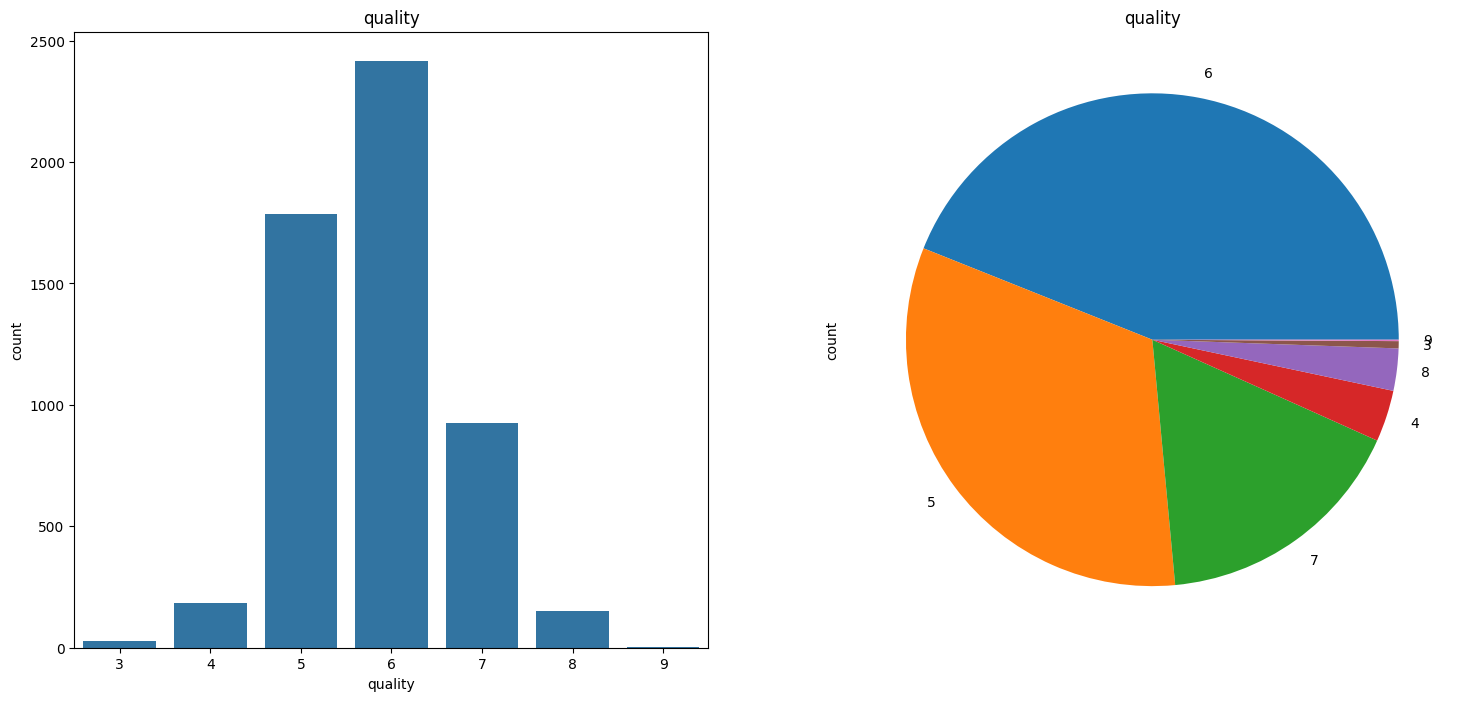

In [23]:
f,ax=plt.subplots(1,2,figsize=(18,8))
train['quality'].value_counts().plot.pie(ax=ax[1])
ax[0].set_title('quality')
ax[0].set_ylabel('')
sns.countplot(x='quality',data=train,ax=ax[0])
ax[1].set_title('quality')
plt.show()

와인의 품질 점수는 5점과 6점에 집중되어 있는 불균형 데이터 이다. 즉. 중간 품질 등급에 많은 와인이 포함된 다는 것을 알 수 있다.

**train분포**

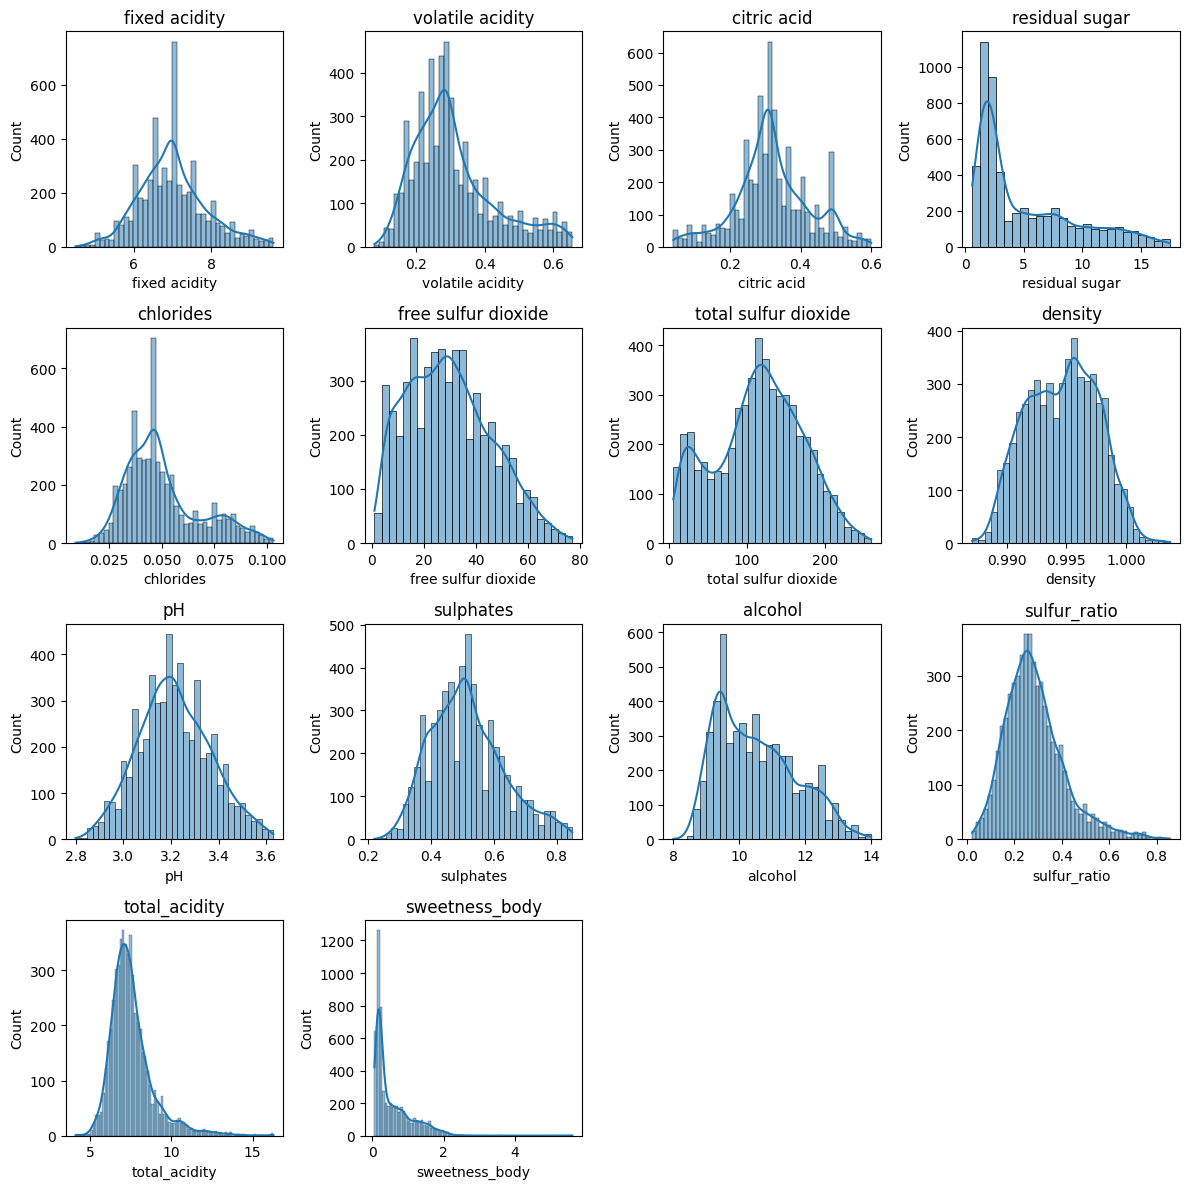

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,12))

numerical_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                   'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                   'pH', 'sulphates', 'alcohol', 'sulfur_ratio', 'total_acidity', 'sweetness_body']

num_plots = len(numerical_cols)
nrows = int(np.ceil(num_plots / 4))
ncols = 4

for i, col in enumerate(numerical_cols):
    plt.subplot(nrows, ncols, i + 1)
    sns.histplot(train[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

각 변수의 분포를 시각화한 결과, residual sugar, chlorides, sulfur dioxide 계열 변수들은 오른쪽으로 치우친 분포를 보여 일부 이상치 가능성이 확인되었다. 반면 pH와 density는 비교적 특정 값 주변에 집중된 안정적인 분포를 보였다. 또한 type 변수는 연속형 변수가 아닌 범주형 변수이므로 별도의 countplot을 통해 분포를 확인하는 것이 적절하다.

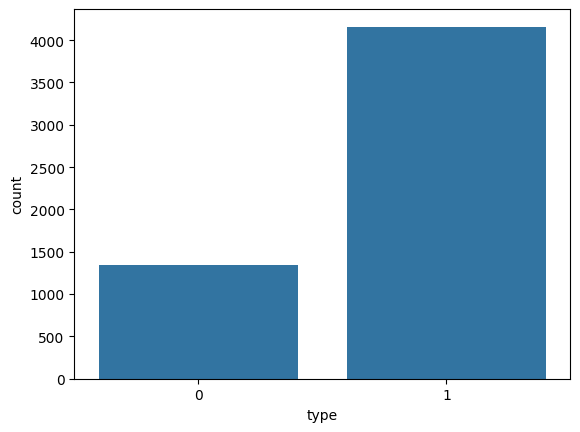

In [25]:
sns.countplot(x='type', data=train)
plt.show()

type 변수는 0보다 1의 비율이 훨씬 높아 클래스 불균형이 존재한다.

**상관계수**

<Axes: >

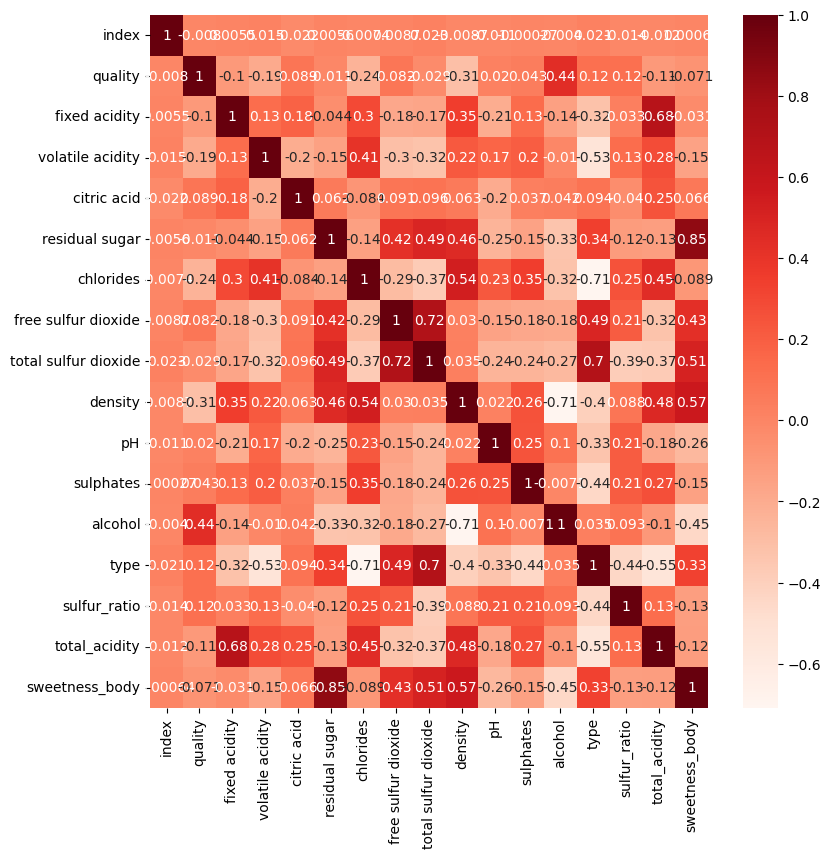

In [26]:
plt.figure(figsize=(9,9))
sns.heatmap(train.corr(), annot=True, cmap='Reds')

이 히트맵은 와인 품질 데이터의 변수들 사이 상관관계를 시각화한 것이다. quality와의 관계를 보면 alcohol이 약 0.44로 가장 높은 양의 상관관계를 보여 알코올 도수가 높을수록 품질 점수가 높아지는 경향이 있음을 확인할 수 있다. 반대로 density와 volatile acidity는 quality와 음의 상관관계를 보여 밀도나 휘발산이 높을수록 품질 점수가 낮아지는 경향을 보인다. 그러나 상관계수가 매우 높은 수준은 아니기 때문에, 와인 품질은 특정 변수 하나로 결정되기보다는 여러 화학적 특성이 복합적으로 작용한다고 볼 수 있다.

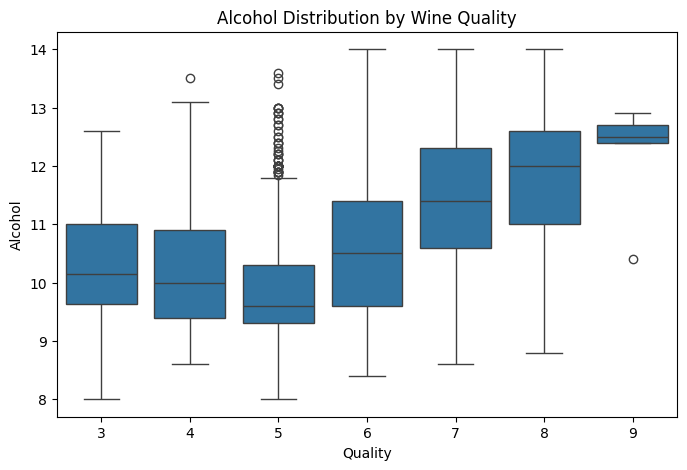

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='quality', y='alcohol', data=train)
plt.title('Alcohol Distribution by Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

앞서 Quality와 상관관계가 비교적 높았던 Alcohol의 도수 분포를 boxplot으로 확인한 결과, 품질 점수가 높아질수록 알코올 도수의 중앙값이 전반적으로 증가하는 경향을 보인다.

In [28]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

continuous_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                   'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                   'pH', 'sulphates', 'alcohol']

train[continuous_cols] = standard_scaler.fit_transform(train[continuous_cols])
test[continuous_cols] = standard_scaler.transform(test[continuous_cols])

# 4. 모델링

# 4-1.결정트리

In [29]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# DecisionTree Classifier 생성
dt_clf = DecisionTreeClassifier(random_state=156)

# 와인 데이터 로딩
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

Training accuracy: 1.0


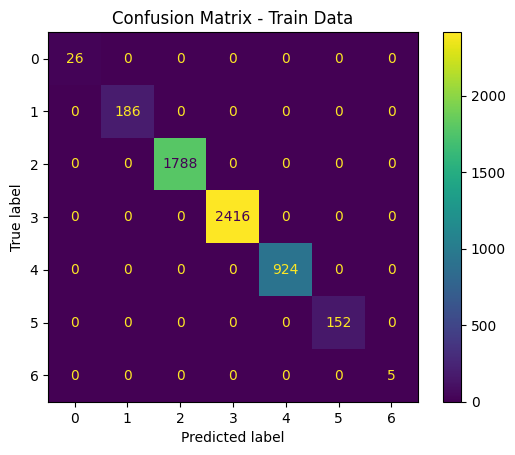

In [30]:
# 1. 데이터 준비
train = train.drop(columns=['index'])  # index 열 제거
test = test.drop(columns=['index'])

# type 열을 0과 1로 인코딩
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train['type'] = label_encoder.fit_transform(train['type'])
test['type'] = label_encoder.transform(test['type'])

# 목표 변수와 특성 분리
X_train = train.drop(columns=['quality'])
y_train = train['quality']

# 2. 파라미터 그리드 설정 및 모델 학습
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# 최적 파라미터로 모델 학습
best_model = grid_search.best_estimator_

# 3. 학습 데이터 성능 평가
y_pred_train = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print("Training accuracy:", train_accuracy)

# 학습 데이터에 대한 혼동 행렬 시각화
conf_matrix = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(conf_matrix)
disp.plot()
plt.title("Confusion Matrix - Train Data")
plt.show()

# 4. test 데이터 예측
y_pred_test = best_model.predict(test)

# 예측 결과를 submission 파일의 quality 열에 저장
submission['quality'] = y_pred_test
submission.to_csv('DT_submit.csv', index=False)

In [31]:
sub_dt = pd.read_csv('DT_submit.csv')
sub_dt.head()

,index,quality
0,0,5
1,1,6
2,2,6
3,3,5
4,4,6


*   예측값의 범위가 3점에서 9점까지 매우 넓게 분포함.
*   단일 트리 모델 특성상 데이터의 개별 특징을 강하게 반영하여, 아주 낮거나(3점) 아주 높은(9점) 품질로 예측하는 경향이 있음.

*   과적합(Overfitting) 가능성이 있어, 실제 정답과 비교 시 오차가 클 수 있음.

# 4-2. 랜덤포레스트

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [33]:
X = train.drop(['quality'], axis=1)
y = train['quality']

In [34]:
# RF

rf_clf=RandomForestClassifier(random_state=156)
rf_clf.fit(X,y)
y_pred_rf=rf_clf.predict(test)

In [35]:
# RF 최종 예측

rf_clf=RandomForestClassifier(random_state=156)
rf_clf.fit(X,y)
y_pred_rf=rf_clf.predict(test)

GridSearchCV를 이용한 하이퍼파라미터 튜닝

In [36]:
# GridSearch

from sklearn.model_selection import GridSearchCV

params={
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2,8,16],
    'min_samples_leaf': [1,5,8]
}

rf_clf_grid=RandomForestClassifier(random_state=156,
                              n_jobs=-1)
grid_cv=GridSearchCV(rf_clf_grid,
                     param_grid=params,
                     cv=5,
                     n_jobs=-1)
grid_cv.fit(X,y)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_jobs=-1, random_state=156),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 5, 8],
                         'min_samples_split': [2, 8, 16],
                         'n_estimators': [100, 200, 300]})

In [37]:
print('최적 하이퍼 파라미터:\n',grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
최고 예측 정확도: 0.6769


In [38]:
# RF (GridSearch 튜닝) 최종 예측

rf_clf=RandomForestClassifier(max_depth=20,
                              min_samples_leaf=1,
                              min_samples_split=2,
                              n_estimators=300,
                              random_state=156)
rf_clf.fit(X,y)
y_pred_rf=rf_clf.predict(test)

In [39]:
# 예측 결과를 submission 파일의 quality 열에 저장
submission['quality'] = y_pred_rf
submission.to_csv('RF_submit.csv', index=False)

In [40]:
sub_rf = pd.read_csv('DT_submit.csv')
sub_rf.head()

,index,quality
0,0,5
1,1,6
2,2,6
3,3,5
4,4,6


*   예측값이 4점에서 8점 사이에 집중되어 있으며, 특히 5~6점에 과반수 이상이 몰려 있음
*   여러 개의 트리를 평균 내는 앙상블 모델 특성상, 극단적인 예측보다는 안정적이고 보수적인 예측 결과를 보여줌.
*   일반화 성능이 높아 단일 트리(DT)보다 실제 평가 점수에서 더 높은 정확도를 보일 가능성이 큼

# 4-3. LightGBM

In [41]:
#Import Library
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

Feature / Target 분리 및 데이터 분할

In [42]:
# Feature/Target 분리
X = train.drop(columns=['quality'])
y = train['quality']

# 학습/검증용 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

LightGBM 모델 학습

In [43]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

# 검증 데이터 예측 및 평가
y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000881 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1481
[LightGBM] [Info] Number of data points in the train set: 4397, number of used features: 12
[LightGBM] [Info] Start training from score -5.344155
[LightGBM] [Info] Start training from score -3.384731
[LightGBM] [Info] Start training from score -1.123248
[LightGBM] [Info] Start training from score -0.822367
[LightGBM] [Info] Start training from score -1.783380
[LightGBM] [Info] Start training from score -3.584657
[LightGBM] [Info] Start training from score -7.002383
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

- 검증 데이터에서 약 60%의 정확도를 보임
- 클래스별로 동일 가중치를 주면 성능이 낮다(macro avg F1 = 0.35) -> 소수 클래스에서 성능이 매우 나쁘다.
- 데이터 많은 클래스 기준으로 보면 괜찮다(weighted avg F1 = 0.60). -> **데이터 불균형**


- 클래스 3,4는 데이터가 너무 적어 모델이 학습하기 어렵다.
- 클래스 5,6은 데이터가 많고 성능이 괜찮다(f1-score)



GridSearchCV를 통한 하이퍼 파라미터 튜닝

In [44]:
from sklearn.model_selection import StratifiedKFold

print("하이퍼파라미터 튜닝(GridSearchCV)")

param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.05],
    'num_leaves': [31, 63],
    'max_depth': [8, -1]
}
lgbm = LGBMClassifier(
    class_weight='balanced',  # 불균형 클래스에 가중치 부여
    random_state=42,
    n_jobs=-1
)

#레이블 불균형 문제를 해결하기 위한 데이터 분할 기법
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid,
                           scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

model_tuned = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Params: {best_params}")
print(f"최적 F1-Macro Score: {best_score:.4f}")

하이퍼파라미터 튜닝(GridSearchCV)
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000659 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1481
[LightGBM] [Info] Number of data points in the train set: 4397, number of used features: 12
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

피처 중요도 확인

In [45]:
y_pred_lgbm = model_tuned.predict(test)

In [46]:
sample_submission['quality'] = y_pred_lgbm

sample_submission.to_csv('LGBM_submit.csv', index=False)

In [47]:
sub_lgbm = pd.read_csv('LGBM_submit.csv')
sub_lgbm.head()

,index,quality
0,0,5
1,1,6
2,2,6
3,3,5
4,4,6


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

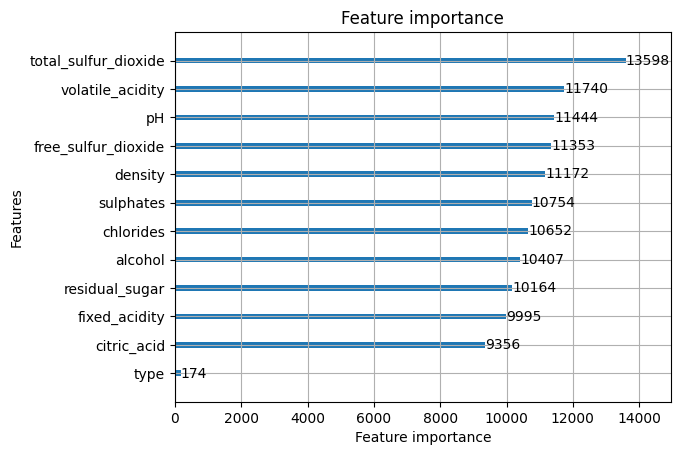

In [48]:
# 피처 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt

model_tuned = grid_search.best_estimator_

plot_importance(model_tuned)

In [49]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [50]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=7, random_state=42)
lgbm = LGBMClassifier(n_estimators=1000, learning_rate=0.05, num_leaves=31, random_state=42)
cat = CatBoostClassifier(n_estimators=1000, learning_rate=0.05, depth=7, random_state=42, verbose=0)

voting_model = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm), ('cat', cat)],
    voting='soft'
)

In [51]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(voting_model, X_resampled, y_resampled, cv=skf, scoring='accuracy')
print(f"교차 검증 평균 정확도: {np.mean(scores):.4f}")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [52]:
voting_model.fit(X_resampled, y_resampled)
pred = voting_model.predict(X_test_scaled)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 16912, number of used features: 15
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [53]:
pred = voting_model.predict(X_test_scaled)
sample_submission['quality'] = pred
sample_submission.to_csv('my_submission.csv', index=False)



*  예측 범위: 3점에서 8점까지 예측하여, 랜덤 포레스트(RF)보다 조금 더 넓은 범위를 커버


*   전체 데이터의 약 82%를 5~6점으로 예측함. 데이터의 주류 경향을 매우 안정적으로 따라가면서도, 아주 낮은 점수(3점)와 높은 점수(8점)도 일부 잡아냄
*  RF 모델과 약 83.4%의 높은 일치도를 보임. 두 모델 모두 앙상블 기법을 사용하기 때문에 전체적인 예측 방향성이 비슷함. 하지만, RF가 5~6점에 더 강하게 쏠려 있다면, LGBM은 소수 등급(4, 7점 등)에 대해 조금 더 세밀하게 판단하는 경향이 있음



